In [ ]:
!pip install idx2numpy

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=8431b271a1b34371f20fa3b307c8a5a694f6a1f46cd6c8ac79deff9a2a8add65
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [ ]:
train_images_file = 'train-images.idx3-ubyte'
train_labels_file = 'train-labels.idx1-ubyte'

In [ ]:
import idx2numpy
import numpy as np

In [ ]:
train_images = idx2numpy.convert_from_file(train_images_file)
train_labels = idx2numpy.convert_from_file(train_labels_file)

In [ ]:
print(f"Loaded training images with shape: {train_images.shape}")
print(f"Loaded training labels with shape: {train_labels.shape}")

Loaded training images with shape: (60000, 28, 28)
Loaded training labels with shape: (60000,)


In [ ]:
import struct
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.metrics import confusion_matrix, classification_report

Data Preprocessing

In [ ]:
test_images_file = 't10k-images.idx3-ubyte'
test_labels_file = 't10k-labels.idx1-ubyte'

In [ ]:
test_images = idx2numpy.convert_from_file(test_images_file)
test_labels = idx2numpy.convert_from_file(test_labels_file)

In [ ]:
print(f"Loaded test images with shape: {test_images.shape}")
print(f"Loaded test labels with shape: {test_labels.shape}")

Loaded test images with shape: (10000, 28, 28)
Loaded test labels with shape: (10000,)


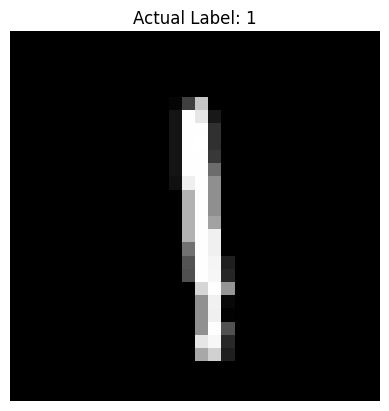

In [ ]:
image_index = 8
plt.imshow(train_images[image_index], cmap='gray')
plt.title(f"Actual Label: {train_labels[image_index]}")
plt.axis('off')
plt.show()

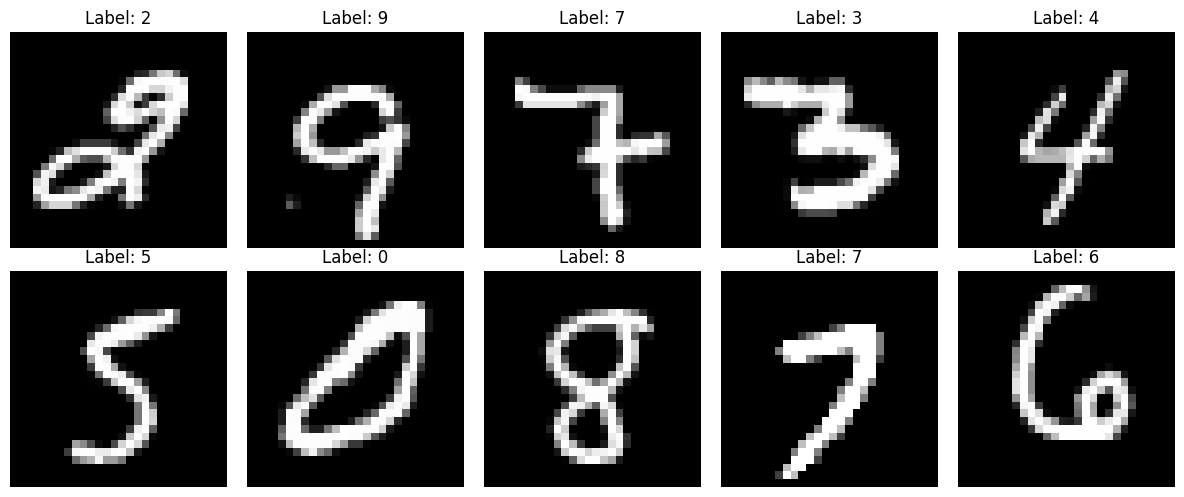

In [ ]:
num_images = 10

random_indices = np.random.choice(train_images.shape[0], num_images, replace=False)

plt.figure(figsize=(12, 5))

for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)  # Create a grid of 2 rows and 5 columns
    plt.imshow(train_images[idx], cmap='gray')
    plt.title(f"Label: {train_labels[idx]}")
    plt.axis('off')


plt.tight_layout()
plt.show()

In [ ]:
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

print(f"New training images shape: {train_images.shape}")
print(f"New test images shape: {test_images.shape}")

New training images shape: (60000, 28, 28, 1)
New test images shape: (10000, 28, 28, 1)


In [ ]:
type(train_images)

numpy.ndarray

In [ ]:
# Convert to float32 and normalize to range [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

print(f"Min pixel value: {train_images.min()}")
print(f"Max pixel value: {train_images.max()}")

print(f"Min pixel value: {test_images.min()}")
print(f"Max pixel value: {test_images.max()}")

Min pixel value: 0.0
Max pixel value: 0.003921568859368563
Min pixel value: 0.0
Max pixel value: 0.003921568859368563


In [ ]:
from tensorflow.keras.utils import to_categorical
train_labels = to_categorical(train_labels, num_classes=10)
test_labels = to_categorical(test_labels, num_classes=10)

print(f"New training labels shape: {train_labels.shape}")
print(f"Example of the first one-hot encoded label: {train_labels[0]}")

New training labels shape: (60000, 10)
Example of the first one-hot encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
train_labels = train_labels.astype('float32')
test_labels = test_labels.astype('float32')

In [ ]:
print(train_images.shape, train_images.dtype)
print(test_images.shape, test_images.dtype)
print(train_labels.shape, train_labels.dtype)
print(test_labels.shape,test_labels.dtype)

(60000, 28, 28, 1) float32
(10000, 28, 28, 1) float32
(60000, 10) float32
(10000, 10) float32


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Initialize the sequential model
model = Sequential([
    # 1. Conv2D + ReLU
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),

    # 2. MaxPooling2D
    MaxPooling2D(pool_size=(2, 2)),

    # 3. Conv2D + ReLU
    Conv2D(64, kernel_size=(3, 3), activation='relu'),

    # 4. MaxPooling2D
    MaxPooling2D(pool_size=(2, 2)),

    # 5. Flatten
    Flatten(),

    # 6. Dense layer + ReLU
    Dense(128, activation='relu'),

    # 7. Dropout layer (disabling 50% of the neurons randomly)
    Dropout(0.5),

    # 8. Dense output layer + Softmax
    Dense(10, activation='softmax')
])

# View the final architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(
    train_images,
    train_labels,
    epochs=10,               # Number of times to iterate over the entire dataset
    batch_size=64,           # Number of images to process at once before updating weights
    validation_split=0.1     # Sets aside 10% of the training data to monitor for overfitting
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5681 - loss: 1.2511 - val_accuracy: 0.9148 - val_loss: 0.3218
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8321 - loss: 0.5304 - val_accuracy: 0.9463 - val_loss: 0.1923
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8761 - loss: 0.4028 - val_accuracy: 0.9577 - val_loss: 0.1472
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8973 - loss: 0.3336 - val_accuracy: 0.9657 - val_loss: 0.1201
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9155 - loss: 0.2793 - val_accuracy: 0.9698 - val_loss: 0.1020
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9260 - loss: 0.2426 - val_accuracy: 0.9733 - val_loss: 0.0895
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9333 - loss: 0.2201 - val_accuracy: 0.9735 - val_loss: 0.0870
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9424 - loss: 0.1957 - val_accuracy: 0

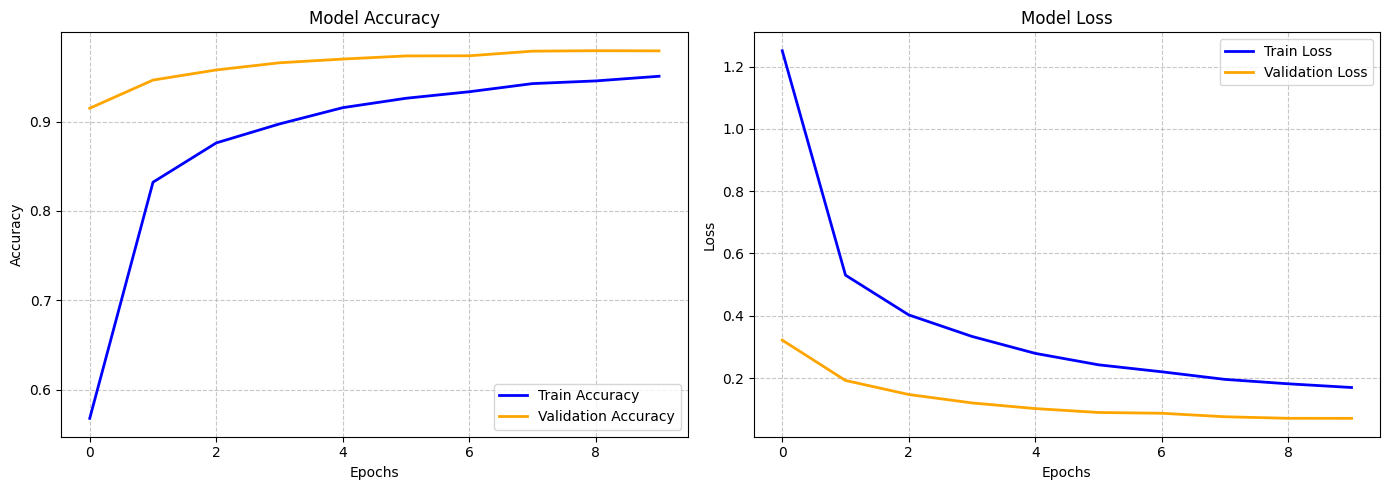

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy ---
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
ax2.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.7)

# Display the plots
plt.tight_layout()
plt.show()

In [34]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

313/313 - 2s - 8ms/step - accuracy: 0.9776 - loss: 0.0716

Test accuracy: 0.9776
Test loss: 0.0716


In [35]:
# Get the raw probability predictions for all 10,000 test images
raw_predictions = model.predict(test_images)

# Collapse the probabilities into final digit predictions
predicted_classes = np.argmax(raw_predictions, axis=1)

# Since test_labels are one-hot encoded, we need to reverse them back to integers to compare
true_classes = np.argmax(test_labels, axis=1)

print(f"Raw prediction shape: {raw_predictions.shape}")
print(f"Final predictions shape: {predicted_classes.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Raw prediction shape: (10000, 10)
Final predictions shape: (10000,)


In [36]:
print("Classification Report:\n")
print(classification_report(true_classes, predicted_classes))

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.97      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.98      0.95      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



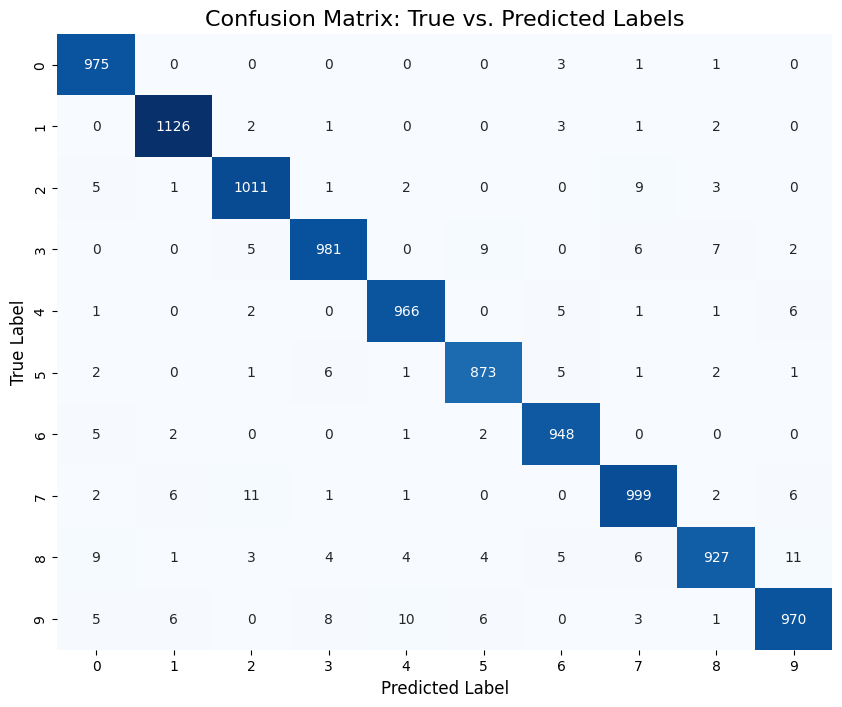

In [37]:
cm = confusion_matrix(true_classes, predicted_classes)

# Visualize it using Seaborn
plt.figure(figsize=(10, 8))
# annot=True adds the numbers, fmt='d' formats them as integers, cmap sets the color
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title('Confusion Matrix: True vs. Predicted Labels', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

Total incorrect predictions: 224


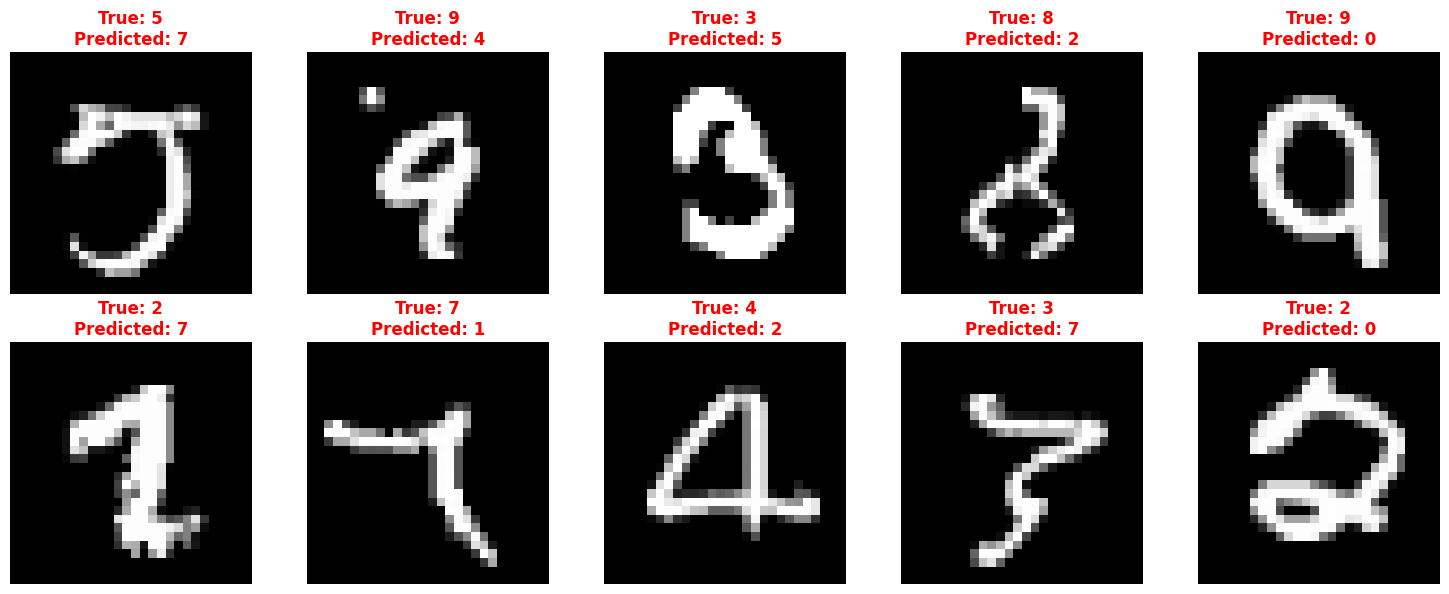

In [38]:
# Find all the indices where the model's guess did NOT match the true label
incorrect_indices = np.where(predicted_classes != true_classes)[0]
print(f"Total incorrect predictions: {len(incorrect_indices)}")

# Pick 10 random mistakes to visualize
num_images = 10
random_incorrect = np.random.choice(incorrect_indices, num_images, replace=False)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(random_incorrect):
    plt.subplot(2, 5, i + 1)

    # Plot the image
    plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')

    # Grab the predicted and true values
    pred = predicted_classes[idx]
    truth = true_classes[idx]

    # Title it exactly as requested
    plt.title(f"True: {truth}\nPredicted: {pred}", color='red', fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [39]:
# PHASE 5: Production-Ready Code & Cloud Demos (brief)

# ---- Step 1: Wrap data loading into a reusable function ----
def load_mnist_data(images_path, labels_path):
    """Loads MNIST images/labels from idx-ubyte files and returns raw numpy arrays."""
    images = idx2numpy.convert_from_file(images_path)
    labels = idx2numpy.convert_from_file(labels_path)
    return images, labels

# ---- Step 2: Wrap model architecture into a reusable function ----
def build_cnn_model():
    """Returns a freshly built and compiled CNN, identical architecture to the one you trained."""
    new_model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    new_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])
    return new_model

# ---- Step 3: Save your ALREADY-TRAINED model to disk ----
# This saves the `model` object you already trained in Phase 3 — not a new one.
model.save('mnist_cnn.keras')
print("Model saved to mnist_cnn.keras")

# ---- Step 4: Prove it reloads correctly without retraining ----
loaded_model = keras.models.load_model('mnist_cnn.keras')
reload_test_loss, reload_test_acc = loaded_model.evaluate(test_images, test_labels, verbose=2)
print(f"Reloaded model test accuracy: {reload_test_acc:.4f}")
# This number should match your original Phase 4 test accuracy (0.9776) exactly,
# confirming the saved file is a faithful, reusable copy of your trained model.

# ---- Step 5: (Optional) Download the model file to your own machine ----
from google.colab import files
files.download('mnist_cnn.keras')

Model saved to mnist_cnn.keras
313/313 - 3s - 10ms/step - accuracy: 0.9776 - loss: 0.0716
Reloaded model test accuracy: 0.9776


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>